In [1]:
#1.Normal paylanmadan 1000 təsadüfi ədəd generasiya et (mean=50, std=10).CDF və PPF qrafiklərini çək.
#P( X < 60 ) ehtimalını CDF ilə hesabla.PPF istifadə edərək 90%-lik percentili tap.

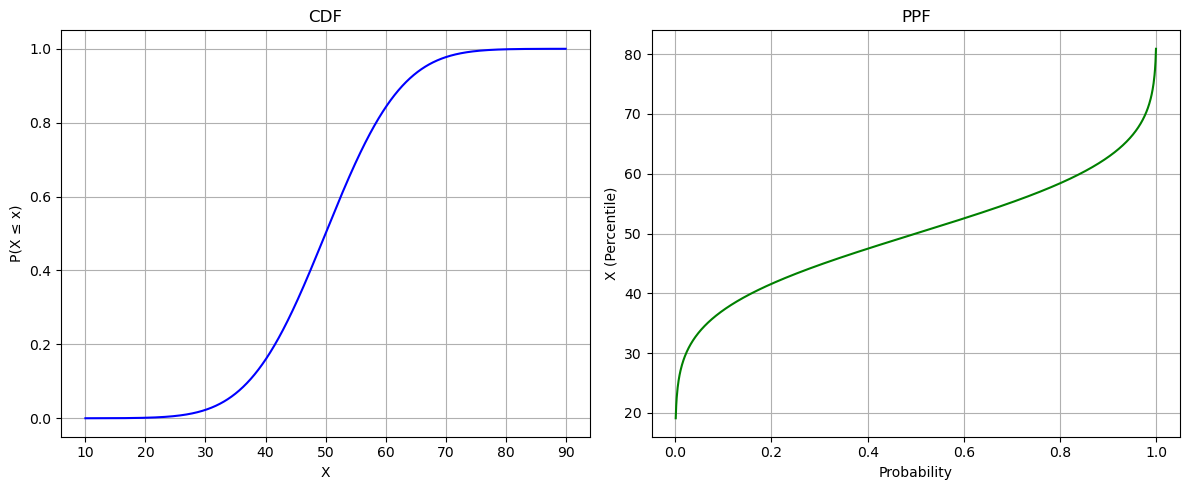

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
mean = 50
std = 10
data = np.random.normal(mean, std, 1000)
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
cdf = norm.cdf(x, mean, std)
p = np.linspace(0, 1, 1000)
ppf = norm.ppf(p, mean, std)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x, cdf, color='blue')
plt.title('CDF')
plt.xlabel('X')
plt.ylabel('P(X ≤ x)')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(p, ppf, color='green')
plt.title('PPF')
plt.xlabel('Probability')
plt.ylabel('X (Percentile)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
print(f'P(X < 60): {norm.cdf(60, mean, std)}')
print(f'0.9 percentile: {norm.ppf(0.9, mean, std)}')

P(X < 60): 0.8413447460685429
0.9 percentile: 62.815515655446006


In [3]:
#2.Bir fabrikdə istehsal olunan lampaların ömrü Exponential(λ=0.1) paylanır.Təsadüfi 1000 nümunə generasiya et.
# Histogram və nəzəri PDF/CDF qrafiklərini çək.P( ömür > 20 ) ehtimalını hesabla.

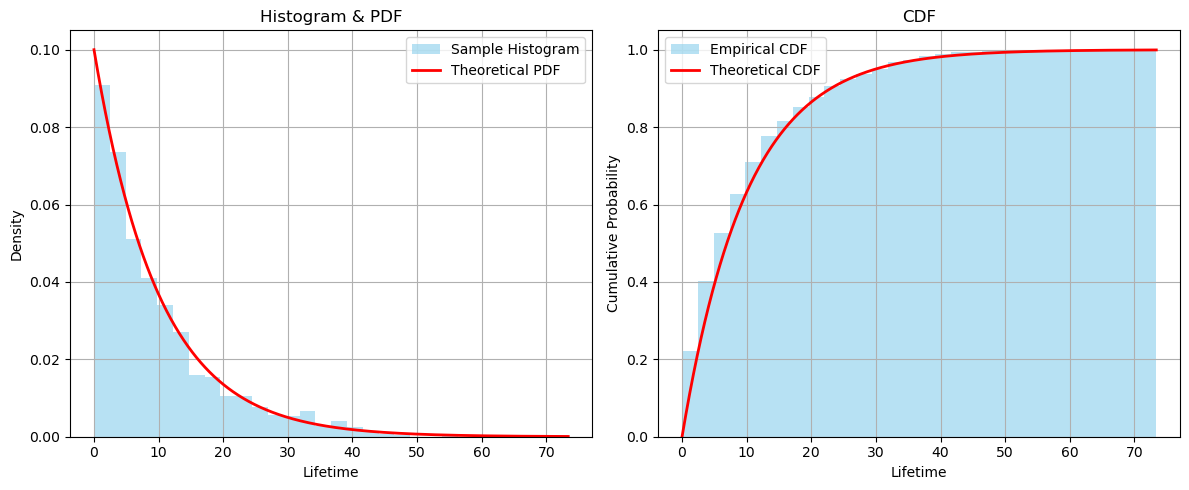

In [10]:
from scipy.stats import expon
lam = 0.1
scale = 1 / lam
data = np.random.exponential(scale, 1000)
x = np.linspace(0, max(data), 1000)
pdf = expon.pdf(x, scale=scale)
cdf = expon.cdf(x, scale=scale)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', label='Sample Histogram')
plt.plot(x, pdf, 'r', lw=2, label='Theoretical PDF')
plt.title('Histogram & PDF')
plt.xlabel('Lifetime')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.hist(data, bins=30, density=True, cumulative=True, alpha=0.6, color='skyblue', label='Empirical CDF')
plt.plot(x, cdf, 'r', lw=2, label='Theoretical CDF')
plt.title('CDF')
plt.xlabel('Lifetime')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
print(f'P (lifetime < 20): {1 - expon.cdf(20, scale=scale)}')

P (lifetime < 20): 0.1353352832366127


In [7]:
#3.Yeni dərs proqramı tətbiq olunub.30 tələbənin əvvəl və sonra ballarını generasiya et.Paired t-test apar.
#Bu proqram effektivdirmi?

In [14]:
from scipy.stats import ttest_rel
before_scores = np.random.normal(loc=70, scale=10, size=30)
after_scores = before_scores + np.random.normal(loc=5, scale=5, size=30)
ttest_rel(before_scores, after_scores)

TtestResult(statistic=np.float64(-5.331040993334749), pvalue=np.float64(1.0109682737468793e-05), df=np.int64(29))

In [9]:
#4.3 müxtəlif dərs metodu ilə tədris olunan qruplar arasında nəticələr fərqlidirmi?
# Hər qrup üçün 25 tələbənin ballarını generasiya et.ANOVA testi apar.
# ANOVA testi apar. Nəticəni şərh et (H₀: hamısının ortaları eynidir).

In [17]:
from scipy.stats import f_oneway
group1 = np.random.randint(60, 80, 25)
group2 = np.random.randint(55, 70, 25)
group3 = np.random.randint(65, 90, 25)
f_oneway(group1, group2, group3)

F_onewayResult(statistic=np.float64(35.25288239815525), pvalue=np.float64(2.118372230292565e-11))

In [11]:
#5.Bir mağazada müştərilərin cinsi (kişi/qadın) ilə məhsul seçimi (3 kateqoriya: A, B, C) arasında əlaqə varmı?
# 200 nəfərlik təsadüfi data yarat.Chi-square testi apar və nəticəni şərh et.

In [18]:
from scipy.stats import chi2_contingency
genders = np.random.choice(["Male", "Female"], size = 200)
rate = np.random.choice(["A", "B", "C"], size = 200)
crosstab = pd.crosstab(genders, rate)
chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=np.float64(2.0892109236772898), pvalue=np.float64(0.3518306025976859), dof=2, expected_freq=array([[40.88, 33.6 , 37.52],
       [32.12, 26.4 , 29.48]]))

In [ ]:
#6.Binomial paylanmadan n=20, p=0.3 üçün:PMF, CDF və PPF qrafiklərini çək.P(X ≥ 10) ehtimalını hesabla.

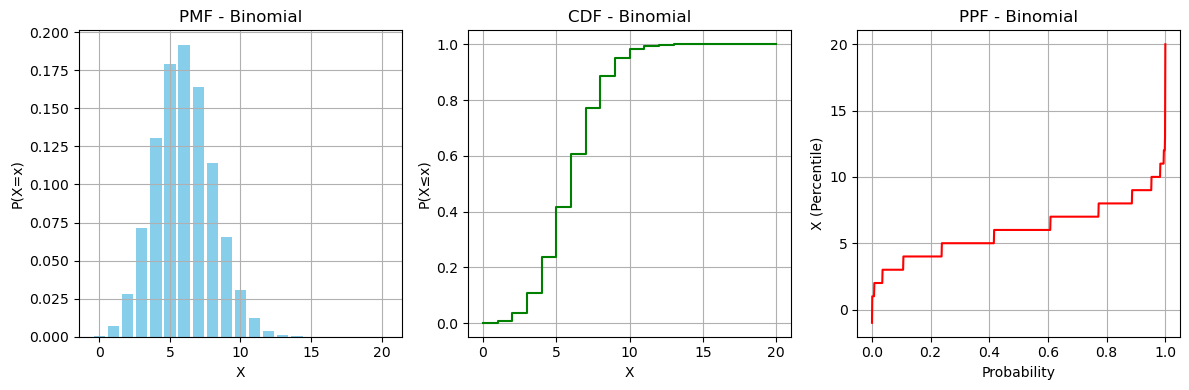

In [19]:
from scipy.stats import binom
n = 20
p = 0.3
x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)
cdf = binom.cdf(x, n, p)
prob = np.linspace(0, 1, 1000)
ppf = binom.ppf(prob, n, p)
plt.figure(figsize=(12,4))

# PMF
plt.subplot(1,3,1)
plt.bar(x, pmf, color='skyblue')
plt.title('PMF - Binomial')
plt.xlabel('X')
plt.ylabel('P(X=x)')
plt.grid(True)

# CDF
plt.subplot(1,3,2)
plt.step(x, cdf, where='post', color='green')
plt.title('CDF - Binomial')
plt.xlabel('X')
plt.ylabel('P(X≤x)')
plt.grid(True)

# PPF
plt.subplot(1,3,3)
plt.plot(prob, ppf, color='red')
plt.title('PPF - Binomial')
plt.xlabel('Probability')
plt.ylabel('X (Percentile)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
print(f'P(X ≥ 10): {1 - binom.cdf(9, n, p)}')

P(X ≥ 10): 0.04796189733134337
